# Jingju MusicXML Tokenizer — v4
**Course:** Analysis of Symbolic Music and Ethnomusicology  
**Dataset:** Jingju Opera Scores Corpus  
**Version history:** v1 core · v2 structural tokens · v3 vocab optimisation · v4 evaluation & export

## Setup

In [2]:
!pip -q install music21

import os, re, csv, json, shutil, tempfile, zipfile, datetime, warnings
from pathlib import Path
from fractions import Fraction
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import List, Optional, Tuple
from math import log2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
warnings.filterwarnings("ignore")

from music21 import converter, stream, note, chord, meter, key, clef
from music21 import instrument as m21inst, pitch as m21pitch
from music21 import bar, dynamics as m21dyn, tempo as m21tempo
from music21 import expressions as m21expr
from music21.clef import clefFromString
from music21.pitch import AccidentalException

try:
    from google.colab import files as _gfiles
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Ready.")

Ready.


## Configuration

In [3]:
STATS = {
    "microtones_quantized": 0,
    "events_skipped":       0,
    "measures_skipped":     0,
    "files_failed":         0,
    "files_tokenized":      0,
    "junk_skipped":         0,
}

CONFIG = {
    "steps_per_quarter":    4,
    "quant_mode":           "nearest",
    "rare_pitch_threshold": 5,
    "rare_lyric_threshold": 3,
    "version":              "v4",
}

STEP = Fraction(1, CONFIG["steps_per_quarter"])

## Data Ingestion

In [4]:
DATA_DIR = Path("/content/dataset")
DATA_DIR.mkdir(parents=True, exist_ok=True)

if IN_COLAB:
    print("Upload corpus ZIP:")
    uploaded = _gfiles.upload()
    for zname in uploaded:
        with zipfile.ZipFile(zname) as z:
            z.extractall(DATA_DIR)
        print(f"  extracted → {DATA_DIR}")
else:
    print(f"Local mode: {DATA_DIR}")

Upload corpus ZIP:


Saving Jingju Scores Dataset.zip to Jingju Scores Dataset (2).zip
  extracted → /content/dataset


## File Collection & Junk Filtering

In [5]:
_EXTENSIONS = {".xml", ".musicxml", ".mxl"}
_SIGNATURES = (b"score-partwise", b"score-timewise", b"part-list")

def is_valid_score(path: Path) -> bool:
    if path.name.startswith(("._", ".")):
        return False
    if "__MACOSX" in str(path):
        return False
    if path.suffix.lower() not in _EXTENSIONS:
        return False
    if path.stat().st_size == 0:
        return False
    try:
        return any(sig in path.read_bytes()[:800] for sig in _SIGNATURES)
    except OSError:
        return False

def gather_scores(root: Path) -> List[Path]:
    return sorted(p for p in root.rglob("*") if p.is_file() and is_valid_score(p))

ALL_FILES = gather_scores(DATA_DIR)
print(f"Found {len(ALL_FILES)} valid MusicXML files")

Found 108 valid MusicXML files


## Rational Arithmetic Utilities

In [6]:
def to_frac(x) -> Fraction:
    if isinstance(x, Fraction):
        return x
    try:
        return Fraction(x).limit_denominator(128)
    except Exception:
        return Fraction(1)

def fmt(f: Fraction) -> str:
    return str(f.numerator) if f.denominator == 1 else f"{f.numerator}/{f.denominator}"

def parse_frac(s: str) -> Fraction:
    s = s.strip()
    if "/" in s:
        a, b = s.split("/", 1)
        return Fraction(int(a), int(b))
    try:
        return Fraction(int(s))
    except ValueError:
        return Fraction(float(s)).limit_denominator(128)

def snap(f: Fraction, grid: Fraction, mode: str = "nearest") -> Fraction:
    if grid <= 0:
        return f
    q = f / grid
    n, d = q.numerator, q.denominator
    k = n // d
    rem = n - k * d
    if mode == "floor":
        pass
    elif mode == "ceil":
        if rem: k += 1
    else:
        if rem * 2 >= d: k += 1
    return Fraction(k) * grid

## Token Emission Helpers

In [7]:
_CLEAN = re.compile(r"[^A-Za-z0-9]+")

def sanitise(s) -> str:
    s = _CLEAN.sub("_", str(s or "").strip())
    return re.sub(r"_+", "_", s).strip("_") or "Unknown"

def resolve_part_name(part, idx: int) -> str:
    for attr in ("partName",):
        v = getattr(part, attr, None)
        if v and str(v).strip():
            return str(v).strip()
    try:
        inst = part.getInstrument(returnDefault=False)
        if inst:
            for a in ("instrumentName", "partName"):
                v = getattr(inst, a, None)
                if v and str(v).strip():
                    return str(v).strip()
    except Exception:
        pass
    pid = getattr(part, "id", None)
    if pid and isinstance(pid, str) and not pid.strip().isdigit():
        return pid.strip()[:64]
    return f"Part{idx}"

def clef_token(c: clef.Clef) -> str:
    sign = getattr(c, "sign", None) or "G"
    line = getattr(c, "line", None)
    return f"CLEF_{sign}_{line if line is not None else 'NA'}"

def timesig_token(ts: meter.TimeSignature) -> str:
    return f"TIME_SIG_{ts.numerator}/{ts.denominator}"

def keysig_token(ks) -> str:
    try:
        k = ks.asKey() if hasattr(ks, "asKey") else ks
        return f"KEY_{sanitise(str(k.tonic).replace('-','b'))}_{sanitise(str(k.mode))}"
    except Exception:
        return "KEY_C_major"

def pitch_token(n: note.Note) -> Optional[str]:
    try:
        name = n.pitch.name.replace("-", "b")
        if n.pitch.octave is None:
            raise ValueError
        return f"PITCH_{name}{n.pitch.octave}"
    except (AccidentalException, Exception):
        try:
            p = m21pitch.Pitch(midi=n.pitch.midi)
            STATS["microtones_quantized"] += 1
            return f"PITCH_{p.name.replace('-','b')}{p.octave}"
        except Exception:
            STATS["events_skipped"] += 1
            return None

def rest_token(r: note.Rest) -> str:
    return f"REST_{getattr(r.duration, 'type', None) or 'unknown'}"

def staff_of(el) -> int:
    sn = getattr(el, "staffNumber", None)
    if sn is not None:
        try: return int(sn)
        except: pass
    return 1

def voice_of(el) -> int:
    try:
        v = el.getContextByClass(stream.Voice)
        if v is not None and getattr(v, "id", None) is not None:
            return int(str(v.id))
    except: pass
    vn = getattr(el, "voiceNumber", None)
    if vn is not None:
        try: return int(vn)
        except: pass
    return 1

## Tokenizer

In [8]:
def tokenize(path: str) -> List[str]:
    p = Path(path)
    if not is_valid_score(p):
        STATS["junk_skipped"] += 1
        return []
    try:
        score = converter.parse(str(p))
    except Exception:
        STATS["files_failed"] += 1
        raise

    grid = STEP
    mode = CONFIG["quant_mode"]
    out: List[str] = ["<BOS>"]
    parts = list(score.parts) if getattr(score, "parts", None) else [score]

    for idx, part in enumerate(parts, 1):
        out.append(f"PART_{sanitise(resolve_part_name(part, idx))}")
        measures = list(part.getElementsByClass(stream.Measure))
        if not measures:
            try:
                measures = list(part.makeMeasures().getElementsByClass(stream.Measure))
            except Exception:
                STATS["measures_skipped"] += 1
                continue

        abs_pos = Fraction(0)

        for m in measures:
            out.append(f"BAR_{m.number if m.number is not None else 0}")
            try:
                bar_len = to_frac(m.barDuration.quarterLength)
            except Exception:
                bar_len = to_frac(getattr(m, "highestTime", 4.0))
            bar_len = snap(bar_len, grid, mode) or Fraction(4)
            out.append(f"MEASURE_LEN_{fmt(bar_len)}")

            flat = m.flatten()
            events: List[Tuple[Fraction, int, List[str]]] = []

            for c in flat.getElementsByClass(clef.Clef):
                off = snap(to_frac(c.offset), grid, mode)
                events.append((off, 1, [clef_token(c)]))
            for ts in flat.getElementsByClass(meter.TimeSignature):
                off = snap(to_frac(ts.offset), grid, mode)
                events.append((off, 2, [timesig_token(ts)]))
            for ks in flat.getElementsByClass(key.KeySignature):
                off = snap(to_frac(ks.offset), grid, mode)
                events.append((off, 3, [keysig_token(ks)]))
            for bl in m.getElementsByClass(bar.Barline):
                off = snap(to_frac(bl.offset), grid, mode)
                if isinstance(bl, bar.Repeat):
                    tag = "REPEAT_FWD" if getattr(bl, "direction", "start") == "start" else "REPEAT_BWD"
                    events.append((off, 0, [tag]))
                else:
                    raw = str(getattr(bl, "style", "") or "")
                    if raw and raw not in ("regular", "", "None"):
                        events.append((off, 0, [f"BARLINE_{re.sub(r'[^A-Za-z0-9]+', '-', raw).strip('-')}"]))
            for d in flat.getElementsByClass(m21tempo.MetronomeMark):
                off = snap(to_frac(d.offset), grid, mode)
                try:
                    events.append((off, 4, [f"TEMPO_{int(float(d.number))}"]))
                except: pass
            for d in flat.getElementsByClass(m21dyn.Dynamic):
                off = snap(to_frac(d.offset), grid, mode)
                events.append((off, 5, [f"DYNAMICS_{d.value}"]))

            for el in flat.notesAndRests:
                try:
                    off     = snap(to_frac(el.offset), grid, mode)
                    abs_off = snap(abs_pos + off, grid, mode)
                    dur     = snap(to_frac(el.duration.quarterLength), grid, mode) or grid

                    s_tok = f"STAFF_{staff_of(el)}"
                    v_tok = f"VOICE_{voice_of(el)}"
                    pb    = f"POS_BAR_{fmt(off)}"
                    pa    = f"POS_ABS_{fmt(abs_off)}"
                    d_tok = f"DUR_{fmt(dur)}"

                    extras: List[str] = []
                    if hasattr(el, "expressions"):
                        if any(isinstance(x, m21expr.Fermata) for x in el.expressions):
                            extras.append("FERMATA")
                    if hasattr(el, "lyrics"):
                        for lyr in el.lyrics:
                            txt = getattr(lyr, "text", None)
                            if txt:
                                extras.append(f"LYRIC_{txt.strip()}")

                    ties: List[str] = []
                    if getattr(el, "tie", None):
                        ties.append(f"TIE_{el.tie.type.upper()}")

                    if isinstance(el, note.Rest):
                        events.append((off, 10, [s_tok, v_tok, pb, pa, rest_token(el), d_tok, *extras]))
                    elif isinstance(el, note.Note):
                        pt = pitch_token(el)
                        if pt is None: continue
                        if el.duration.isGrace:
                            events.append((off, 9, [f"GRACE_{pt}"]))
                            continue
                        events.append((off, 10, [s_tok, v_tok, pb, pa, pt, *ties, d_tok, *extras]))
                    elif isinstance(el, chord.Chord):
                        for pch in sorted(el.pitches, key=lambda p: p.midi):
                            pt = pitch_token(note.Note(pch))
                            if pt:
                                events.append((off, 10, [s_tok, v_tok, pb, pa, pt, *ties, d_tok, *extras]))
                except Exception:
                    STATS["events_skipped"] += 1

            events.sort(key=lambda x: (x[0], x[1]))
            for _, __, toks in events:
                out.extend(toks)
            abs_pos += bar_len

    out.append("<EOS>")
    STATS["files_tokenized"] += 1
    return out

## Demo — First File

In [9]:
demo_path   = ALL_FILES[0] if ALL_FILES else None
demo_tokens = []

if demo_path:
    demo_tokens = tokenize(str(demo_path))
    print(f"File  : {demo_path.name}")
    print(f"Tokens: {len(demo_tokens):,}  |  Unique: {len(set(demo_tokens)):,}")
    print()
    for i, t in enumerate(demo_tokens[:60]):
        print(f"  {i:3d}  {t}")
else:
    print("No files found.")

File  : daeh-CanQiQi-WuLongZuo.xml
Tokens: 8,382  |  Unique: 1,059

    0  <BOS>
    1  PART_Piano
    2  BAR_1
    3  MEASURE_LEN_4
    4  CLEF_G_2
    5  TIME_SIG_4/4
    6  KEY_E_major
    7  STAFF_1
    8  VOICE_1
    9  POS_BAR_0
   10  POS_ABS_0
   11  REST_quarter
   12  DUR_1
   13  STAFF_1
   14  VOICE_1
   15  POS_BAR_1
   16  POS_ABS_1
   17  REST_quarter
   18  DUR_1
   19  STAFF_1
   20  VOICE_1
   21  POS_BAR_2
   22  POS_ABS_2
   23  REST_eighth
   24  DUR_1/2
   25  STAFF_1
   26  VOICE_1
   27  POS_BAR_5/2
   28  POS_ABS_5/2
   29  PITCH_C#4
   30  DUR_1/2
   31  STAFF_1
   32  VOICE_1
   33  POS_BAR_3
   34  POS_ABS_3
   35  PITCH_G#4
   36  DUR_1/2
   37  STAFF_1
   38  VOICE_1
   39  POS_BAR_7/2
   40  POS_ABS_7/2
   41  PITCH_F#4
   42  DUR_1/2
   43  BAR_2
   44  MEASURE_LEN_4
   45  STAFF_1
   46  VOICE_1
   47  POS_BAR_0
   48  POS_ABS_4
   49  PITCH_E4
   50  DUR_1/2
   51  STAFF_1
   52  VOICE_1
   53  POS_BAR_1/2
   54  POS_ABS_9/2
   55  PITCH_C#4
   56  DUR

## Batch Tokenisation

In [10]:
RESULTS:     List[dict] = []
TOKEN_CACHE: dict = {}

for i, fp in enumerate(ALL_FILES, 1):
    if not is_valid_score(fp):
        STATS["junk_skipped"] += 1
        RESULTS.append({"filename": fp.name, "status": "SKIP", "n_tokens": 0, "error": "junk"})
        continue
    try:
        toks = tokenize(str(fp))
        TOKEN_CACHE[fp.name] = toks
        RESULTS.append({"filename": fp.name, "status": "OK", "n_tokens": len(toks), "error": ""})
        print(f"  [{i:3d}/{len(ALL_FILES)}] {fp.name:<55} {len(toks):>6} tokens")
    except Exception as e:
        RESULTS.append({"filename": fp.name, "status": "FAIL", "n_tokens": 0, "error": str(e)[:100]})
        print(f"  [{i:3d}/{len(ALL_FILES)}] FAIL  {fp.name}: {e}")

ok = [r for r in RESULTS if r["status"] == "OK"]
counts = [r["n_tokens"] for r in ok]
print(f"\nOK {len(ok)} / FAIL {STATS['files_failed']} / SKIP {STATS['junk_skipped']}")
if counts:
    print(f"Tokens  avg {sum(counts)/len(counts):.0f}  min {min(counts)}  max {max(counts)}")

  [  1/108] daeh-CanQiQi-WuLongZuo.xml                                8382 tokens
  [  2/108] daeh-LiYanFei-DaBaoGuo.xml                                6610 tokens
  [  3/108] daeh-LiYanFei-ErJinGong.xml                               5626 tokens
  [  4/108] daeh-NaRiFeng-YuanXiaoMi.xml                              4403 tokens
  [  5/108] daeh-NuZiYou-TouJunBieYao.xml                             3323 tokens
  [  6/108] daeh-SunShangXiang-BieHuangGong.xml                       6697 tokens
  [  7/108] daeh-TanHongYan-HuoXiaoYu.xml                            10101 tokens
  [  8/108] daeh-WangChunE-SanNiangJiaoZi.xml                        12469 tokens
  [  9/108] daeh-WeiKaiYan-DouEYuan.musicxml                         17162 tokens
  [ 10/108] daeh-WuDuanQiao-BiYuZan.xml                              14176 tokens
  [ 11/108] daeh-XiaoNuCai-SanNiangJiaoZi.xml                         1803 tokens
  [ 12/108] daeh-YangYuHuan-TaiZheWaiZhuan.musicxml                   2821 tokens
  [ 13/108] daeh

## Corpus Statistics & Vocabulary Analysis

In [11]:
corpus: List[str] = []
for toks in TOKEN_CACHE.values():
    corpus.extend(toks)

freq  = Counter(corpus)
vocab = set(freq)
total = len(corpus)

print(f"Corpus size : {total:,} tokens")
print(f"Vocabulary  : {len(vocab):,} unique")

def H(counts: Counter) -> Tuple[float, float, float]:
    n = sum(counts.values())
    p = np.array([c/n for c in counts.values()], dtype=float)
    h = -np.sum(p * np.log2(p + 1e-15))
    hmax = log2(len(counts)) if len(counts) > 1 else 1.0
    return h, hmax, h/hmax

h, hmax, eff = H(freq)
print(f"\nEntropy     : {h:.3f} bits  (max {hmax:.3f}, eff {eff:.3f})")

cat_freq: Counter = Counter()
cat_vocab: dict   = defaultdict(set)
for tok, cnt in freq.items():
    cat = "BOUNDARY" if tok in ("<BOS>","<EOS>") else (tok.split("_")[0] if "_" in tok else tok)
    cat_freq[cat]  += cnt
    cat_vocab[cat].add(tok)

print()
print(f"{'Category':<14} {'Tokens':>10} {'Vocab':>8} {'%':>8}")
print(f"{'─'*14} {'─'*10} {'─'*8} {'─'*8}")
for cat, cnt in cat_freq.most_common():
    print(f"{cat:<14} {cnt:>10,} {len(cat_vocab[cat]):>8} {cnt/total*100:>7.1f}%")

Corpus size : 694,560 tokens
Vocabulary  : 6,861 unique

Entropy     : 6.485 bits  (max 12.744, eff 0.509)

Category           Tokens    Vocab        %
────────────── ────────── ──────── ────────
POS               210,532     4003    30.3%
STAFF             105,266        1    15.2%
VOICE             105,266        1    15.2%
DUR               105,266       25    15.2%
PITCH              92,402       25    13.3%
BAR                22,837      470     3.3%
MEASURE            22,837        8     3.3%
REST               12,864       10     1.9%
LYRIC              10,039     2053     1.4%
GRACE               3,638       18     0.5%
TIE                 2,058        3     0.3%
TIME                  263        4     0.0%
BARLINE               232      232     0.0%
PART                  222        1     0.0%
CLEF                  222        1     0.0%
KEY                   222        1     0.0%
BOUNDARY              216        2     0.0%
FERMATA               150        1     0.0%
REPEAT      

## Vocabulary Optimisation — Rare Pitch Merging & Lyric Closed Vocab

In [12]:
thr = CONFIG["rare_pitch_threshold"]

_SEMIS = {"C":0,"D":2,"E":4,"F":5,"G":7,"A":9,"B":11}

def pitch_cents(name: str) -> float:
    step  = name[0].upper()
    alter = name[1:].replace("b","-") if len(name) > 1 else ""
    acc   = {"":0,"#":100,"b":-100,"##":200,"bb":-200}.get(alter, 0)
    return _SEMIS.get(step, 0) * 100 + acc

rare_pitch   = [(t,c) for t,c in freq.items() if t.startswith("PITCH_") and c < thr]
common_pitch = {t for t,c in freq.items() if t.startswith("PITCH_") and c >= thr}
merged_freq  = Counter(freq)
merge_map: dict = {}

for rare, _ in rare_pitch:
    payload = rare[6:]
    i = len(payload)-1
    while i >= 0 and (payload[i].isdigit() or payload[i]=="-"): i -= 1
    rare_step = payload[0].upper()
    rare_c    = pitch_cents(payload[:i+1])
    best, best_d = rare, float("inf")
    for cand in common_pitch:
        cp = cand[6:]; j = len(cp)-1
        while j >= 0 and (cp[j].isdigit() or cp[j]=="-"): j -= 1
        if cp[0].upper() != rare_step: continue
        d = abs(pitch_cents(cp[:j+1]) - rare_c)
        if d < best_d: best, best_d = cand, d
    if best != rare:
        merge_map[rare] = best
        cnt = merged_freq.pop(rare, 0)
        merged_freq[best] += cnt

print(f"Rare PITCH tokens  : {len(rare_pitch)}")
print(f"Merged to neighbour: {len(merge_map)}")

lthr       = CONFIG["rare_lyric_threshold"]
lyric_all  = {t:c for t,c in freq.items() if t.startswith("LYRIC_")}
lyric_keep = {t for t,c in lyric_all.items() if c >= lthr}
lyric_rare = {t for t,c in lyric_all.items() if c <  lthr}
print(f"\nLyric vocab full   : {len(lyric_all)}")
print(f"Lyric vocab kept   : {len(lyric_keep)}  (>= {lthr} occ)")
print(f"Mapped to <UNK>    : {len(lyric_rare)}")

def kl(p: Counter, q: Counter) -> float:
    V = set(p)|set(q); sz = len(V)
    tp, tq = sum(p.values()), sum(q.values())
    if not tp or not tq: return float("inf")
    val = 0.0
    for t in V:
        pi = (p.get(t,0)+1)/(tp+sz)
        qi = (q.get(t,0)+1)/(tq+sz)
        val += pi * log2(pi/qi)
    return val

kl_val = kl(freq, merged_freq)
hm, hmmax, effm = H(merged_freq)
print(f"\nKL(original ‖ merged) = {kl_val:.6f} bits")
print(f"Post-merge vocab size  : {len(set(k for k,v in merged_freq.items() if v>0)):,}")
print(f"Post-merge entropy     : {hm:.3f} bits  (eff {effm:.3f})")

Rare PITCH tokens  : 7
Merged to neighbour: 7

Lyric vocab full   : 2053
Lyric vocab kept   : 804  (>= 3 occ)
Mapped to <UNK>    : 1249

KL(original ‖ merged) = 0.000017 bits
Post-merge vocab size  : 6,854
Post-merge entropy     : 6.485 bits  (eff 0.509)


## Corpus Visualisations — Token Distribution

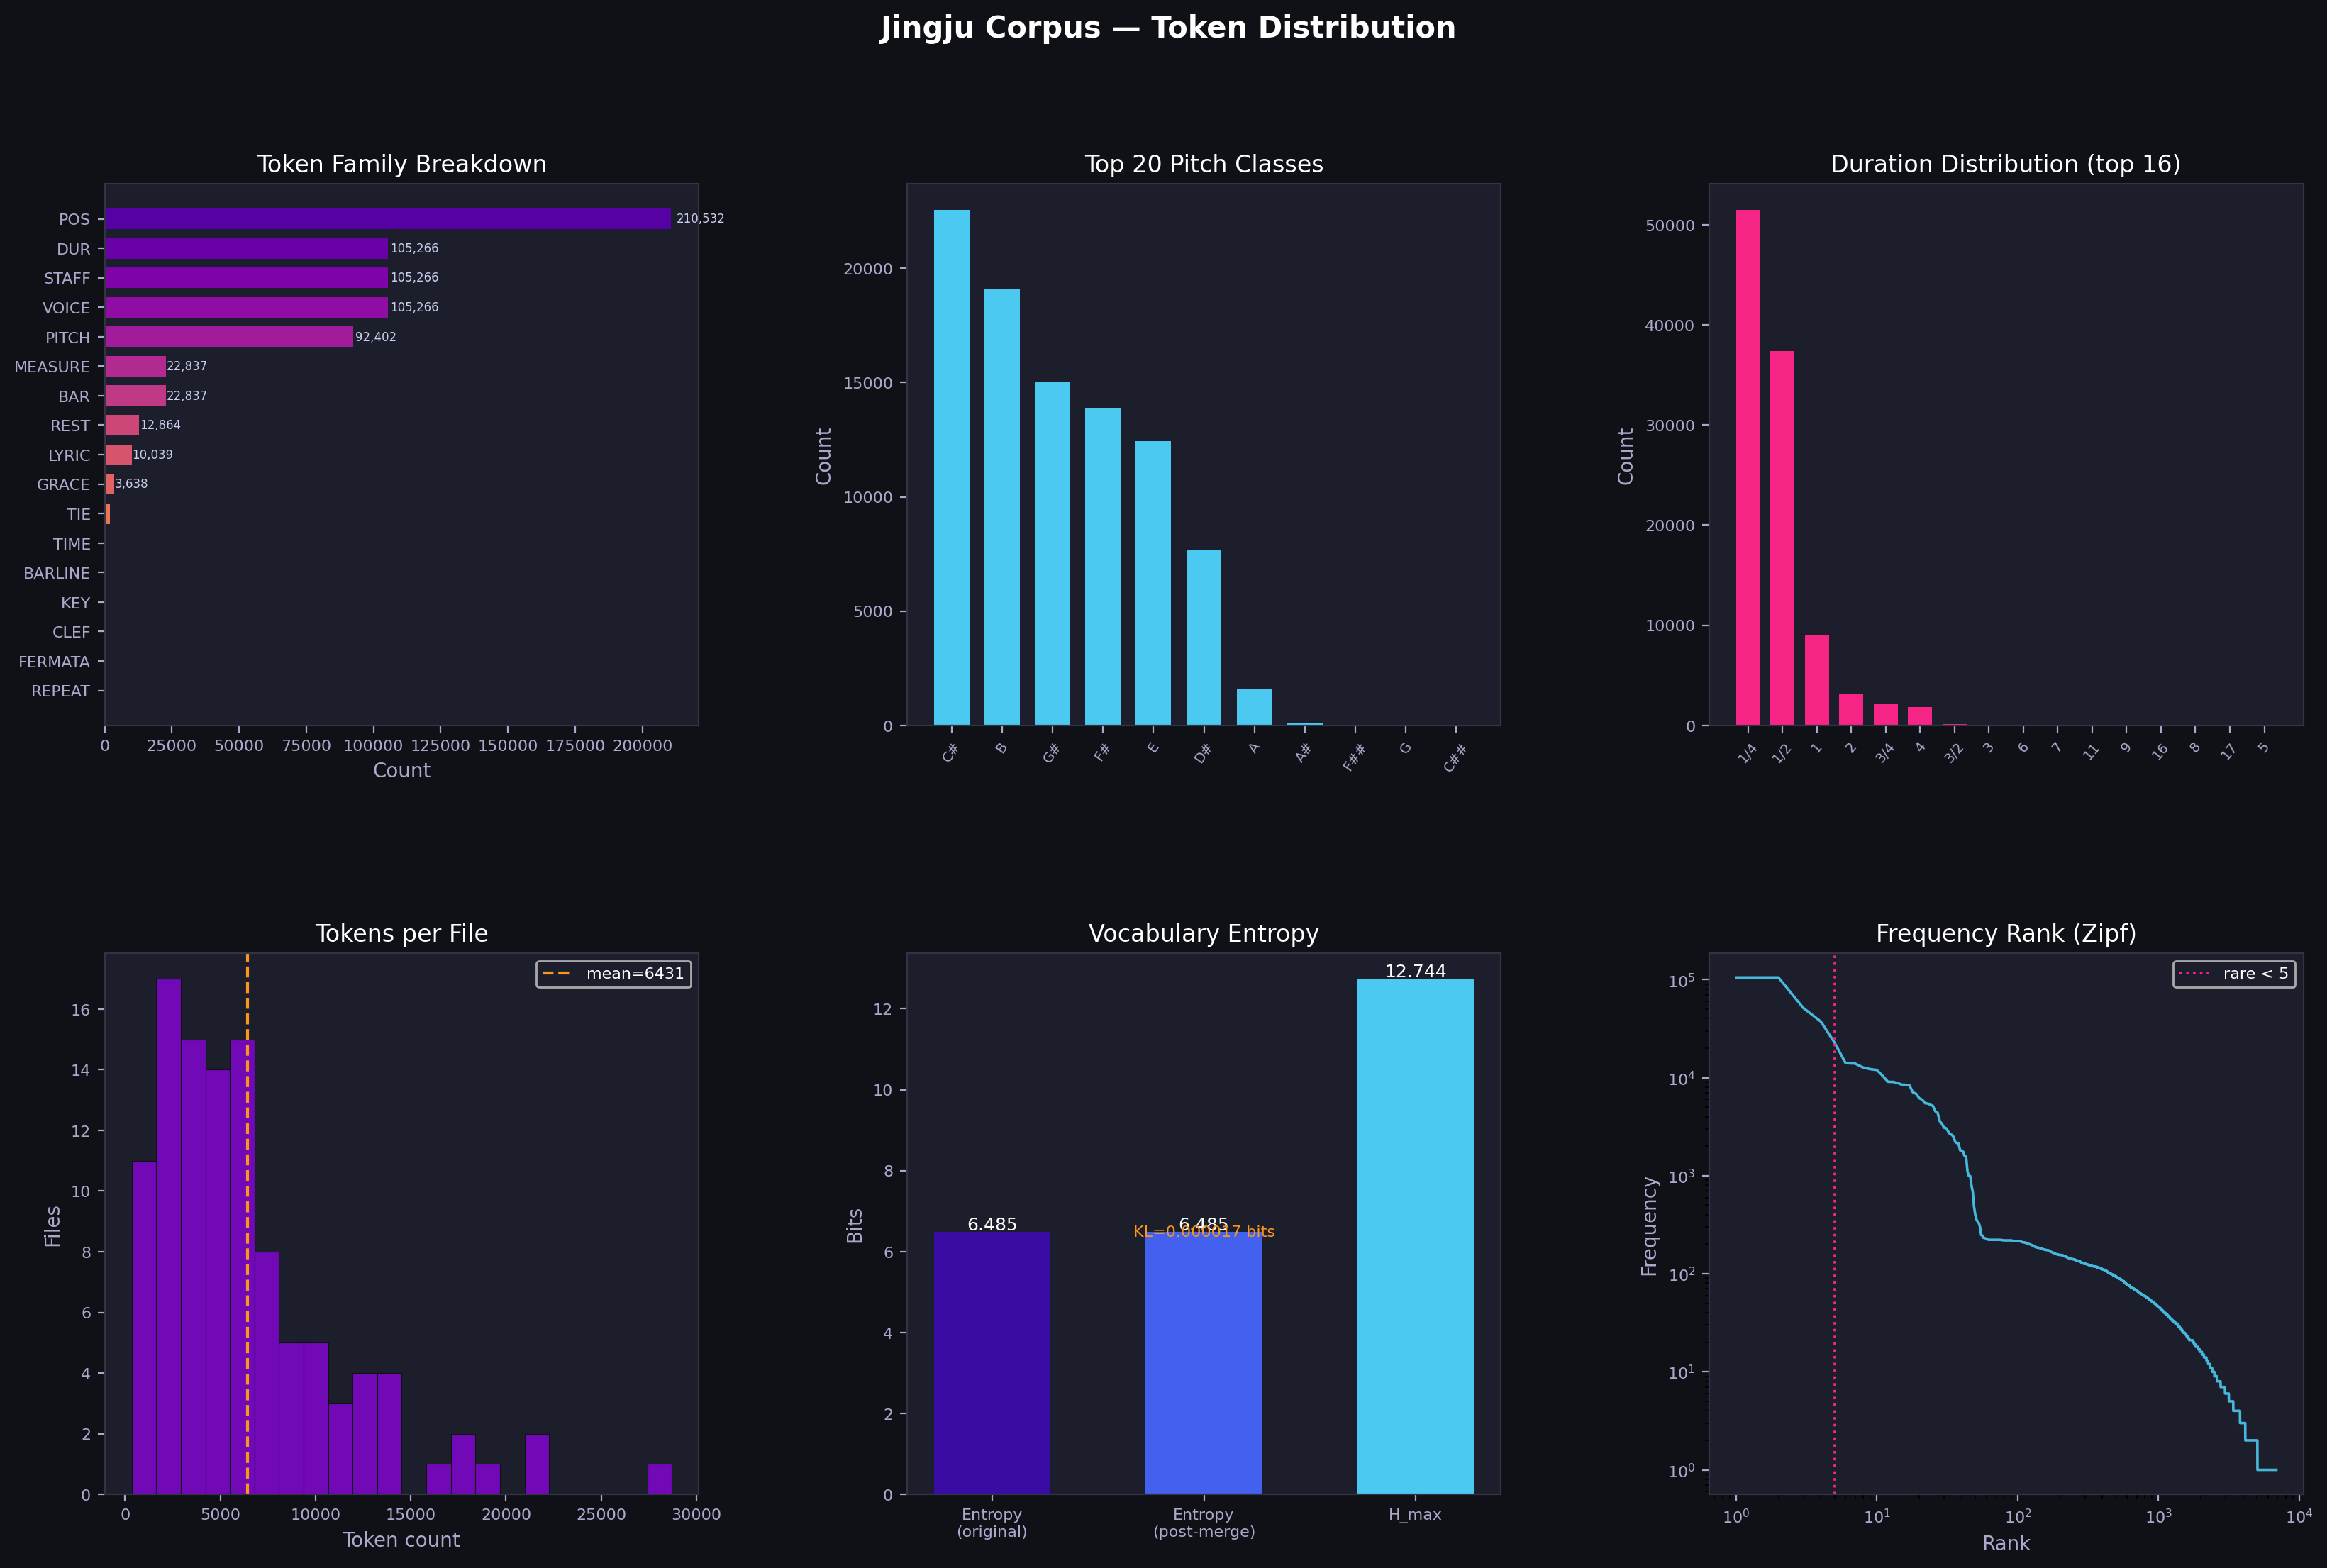

Saved corpus_distribution.png


In [13]:
SUBMISSION_DIR = Path("/content/submission")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

_DARK   = "#0f1117"
_PANEL  = "#1c1f2b"
_ACCENT = ["#4cc9f0","#f72585","#7209b7","#3a0ca3","#4361ee","#4cc9f0","#560bad"]

def dark_ax(ax):
    ax.set_facecolor(_PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333344")
    ax.tick_params(colors="#aaaacc", labelsize=8)
    ax.xaxis.label.set_color("#aaaacc")
    ax.yaxis.label.set_color("#aaaacc")
    ax.title.set_color("white")
    return ax

fig = plt.figure(figsize=(20, 12), facecolor=_DARK)
fig.suptitle("Jingju Corpus — Token Distribution", color="white", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = dark_ax(fig.add_subplot(gs[0, 0]))
fams = ["PITCH","DUR","POS","STAFF","VOICE","MEASURE","REST","BAR","TIE",
        "LYRIC","KEY","TIME","CLEF","TEMPO","DYNAMICS","REPEAT","BARLINE","GRACE","FERMATA"]
fam_cnt = {f: sum(c for t,c in freq.items() if t.startswith(f"{f}_") or t == f) for f in fams}
fc = [(k,v) for k,v in sorted(fam_cnt.items(), key=lambda x:-x[1]) if v > 0]
cols = plt.cm.plasma(np.linspace(0.15, 0.95, len(fc)))
bars = ax1.barh([x[0] for x in fc], [x[1] for x in fc], color=cols, edgecolor="none", height=0.7)
ax1.invert_yaxis()
ax1.set_title("Token Family Breakdown"); ax1.set_xlabel("Count")
for bar_obj, (_, v) in zip(bars, fc):
    if v > total*0.005:
        ax1.text(v*1.01, bar_obj.get_y()+bar_obj.get_height()/2, f"{v:,}", va="center", fontsize=6, color="#ccccee")

ax2 = dark_ax(fig.add_subplot(gs[0, 1]))
pb = Counter()
for t,c in freq.items():
    if not t.startswith("PITCH_"): continue
    pay = t[6:]; i = len(pay)-1
    while i>=0 and (pay[i].isdigit() or pay[i]=="-"): i-=1
    pb[pay[:i+1]] += c
top_pb = pb.most_common(20)
ax2.bar([x[0] for x in top_pb], [x[1] for x in top_pb], color=_ACCENT[0], edgecolor="none", width=0.7)
ax2.set_title("Top 20 Pitch Classes"); ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=55, labelsize=7)

ax3 = dark_ax(fig.add_subplot(gs[0, 2]))
dur_toks = sorted([(t,c) for t,c in freq.items() if t.startswith("DUR_")], key=lambda x:-x[1])[:16]
ax3.bar([x[0][4:] for x in dur_toks], [x[1] for x in dur_toks], color=_ACCENT[1], edgecolor="none", width=0.7)
ax3.set_title("Duration Distribution (top 16)"); ax3.set_ylabel("Count")
ax3.tick_params(axis="x", rotation=50, labelsize=7)

ax4 = dark_ax(fig.add_subplot(gs[1, 0]))
tok_counts = [r["n_tokens"] for r in RESULTS if r["status"]=="OK"]
ax4.hist(tok_counts, bins=22, color=_ACCENT[2], edgecolor=_DARK, linewidth=0.4)
ax4.axvline(np.mean(tok_counts), color="#f8961e", linestyle="--", linewidth=1.5,
            label=f"mean={np.mean(tok_counts):.0f}")
ax4.set_title("Tokens per File"); ax4.set_xlabel("Token count"); ax4.set_ylabel("Files")
ax4.legend(fontsize=8, facecolor=_PANEL, labelcolor="white")

ax5 = dark_ax(fig.add_subplot(gs[1, 1]))
b5 = ax5.bar(["Entropy\n(original)", "Entropy\n(post-merge)", "H_max"],
             [h, hm, hmax], color=[_ACCENT[3], _ACCENT[4], _ACCENT[5]], edgecolor="none", width=0.55)
for b, v in zip(b5, [h, hm, hmax]):
    ax5.text(b.get_x()+b.get_width()/2, v+0.05, f"{v:.3f}", ha="center", fontsize=9, color="white")
ax5.text(1, hmax*0.5, f"KL={kl_val:.6f} bits", ha="center", fontsize=8, color="#f8961e")
ax5.set_title("Vocabulary Entropy"); ax5.set_ylabel("Bits")

ax6 = dark_ax(fig.add_subplot(gs[1, 2]))
sorted_freqs = sorted(freq.values(), reverse=True)
ax6.loglog(range(1, len(sorted_freqs)+1), sorted_freqs, color=_ACCENT[0], linewidth=1.3, alpha=0.9)
ax6.axvline(thr, color=_ACCENT[1], linestyle=":", linewidth=1.3, label=f"rare < {thr}")
ax6.set_title("Frequency Rank (Zipf)"); ax6.set_xlabel("Rank"); ax6.set_ylabel("Frequency")
ax6.legend(fontsize=8, facecolor=_PANEL, labelcolor="white")

plt.savefig(SUBMISSION_DIR/"corpus_distribution.png", dpi=150, bbox_inches="tight", facecolor=_DARK)
plt.show()
print("Saved corpus_distribution.png")

## Token Validation — All 12 Required Families

In [14]:
REQUIRED = [
    ("<BOS>",     lambda t: t == "<BOS>"),
    ("<EOS>",     lambda t: t == "<EOS>"),
    ("PART_",     lambda t: t.startswith("PART_")),
    ("CLEF_",     lambda t: t.startswith("CLEF_")),
    ("TIME_SIG_", lambda t: t.startswith("TIME_SIG_")),
    ("KEY_",      lambda t: t.startswith("KEY_")),
    ("PITCH_",    lambda t: t.startswith("PITCH_")),
    ("DUR_",      lambda t: t.startswith("DUR_")),
    ("POS_BAR_",  lambda t: t.startswith("POS_BAR_")),
    ("POS_ABS_",  lambda t: t.startswith("POS_ABS_")),
    ("REST_",     lambda t: t.startswith("REST_")),
    ("BAR_",      lambda t: t.startswith("BAR_")),
]
OPTIONAL = ["VOICE_","STAFF_","MEASURE_LEN_","REPEAT_","BARLINE_",
            "FERMATA","TEMPO_","DYNAMICS_","LYRIC_","GRACE_","TIE_"]

def validate(tokens: List[str], label: str = "") -> bool:
    ok = True
    for name, fn in REQUIRED:
        if not any(fn(t) for t in tokens):
            print(f"  WARN [{label}]: missing '{name}'")
            ok = False

    prev_max = Fraction(0); bar_vals = []
    for tok in tokens:
        if tok.startswith("BAR_"):
            if bar_vals: prev_max = max(bar_vals)
            bar_vals = []
        elif tok.startswith("POS_ABS_"):
            v = parse_frac(tok[8:])
            bar_vals.append(v)
            if v < prev_max - Fraction(1):
                print(f"  NOTE [{label}]: POS_ABS resets within bar (expected for multi-voice)")
                break

    for t in tokens:
        if t.startswith("DUR_") and parse_frac(t[4:]) <= 0:
            print(f"  WARN [{label}]: non-positive duration {t}")
            ok = False

    found_opt = [p for p in OPTIONAL if any(t.startswith(p) if p != "FERMATA" else t==p for t in tokens)]
    if ok:
        print(f"  OK [{label}]: all 12 required families present")
    print(f"  Optional families: {found_opt}")
    return ok

if demo_tokens:
    validate(demo_tokens, demo_path.name if demo_path else "demo")

  NOTE [daeh-CanQiQi-WuLongZuo.xml]: POS_ABS resets within bar (expected for multi-voice)
  OK [daeh-CanQiQi-WuLongZuo.xml]: all 12 required families present
  Optional families: ['VOICE_', 'STAFF_', 'MEASURE_LEN_', 'BARLINE_', 'LYRIC_', 'GRACE_', 'TIE_']


## Detokenizer

In [16]:
@dataclass(frozen=True)
class EventKey:
    staff: int; voice: int; pos: Fraction; dur: Fraction

def decode_clef(tok: str) -> clef.Clef:
    parts = tok.split("_")
    sign  = parts[1] if len(parts)>1 else "G"
    line  = parts[2] if len(parts)>2 else "NA"
    try:    return clefFromString(sign if line=="NA" else f"{sign}{line}")
    except: return clef.TrebleClef()

def decode_pitch(tok: str) -> Tuple[str, int]:
    pay = tok[6:]; i = len(pay)-1
    while i>=0 and (pay[i].isdigit() or pay[i]=="-"): i-=1
    return pay[:i+1].replace("b","-"), int(pay[i+1:])

def detokenize(tokens: List[str]) -> stream.Score:
    sc = stream.Score()
    part = meas = mlen = None
    pending_changes: List[Tuple[Fraction,object]] = []
    pg: dict = defaultdict(list)
    rg: dict = {}
    sn=vn=1; pos=Fraction(0)
    hp=hs=hv=False
    pp: List[Tuple[str,int]] = []
    pr = pt = None

    def flush():
        nonlocal meas, pg, rg, pending_changes, mlen
        if part is None or meas is None: return
        for off,el in sorted(pending_changes,key=lambda x:x[0]):
            meas.insert(float(off),el)
        for k in sorted(set(list(pg)+list(rg)),key=lambda k:(k.pos,k.staff,k.voice)):
            if k in rg:
                r=note.Rest(); r.duration.quarterLength=float(k.dur)
                meas.insert(float(k.pos),r)
            else:
                pitches=pg.get(k,[])
                if not pitches: continue
                if len(pitches)==1:
                    pn,ov=pitches[0]; n=note.Note(f"{pn}{ov}")
                    n.duration.quarterLength=float(k.dur); meas.insert(float(k.pos),n)
                else:
                    ch=chord.Chord([f"{pn}{ov}" for pn,ov in pitches])
                    ch.duration.quarterLength=float(k.dur); meas.insert(float(k.pos),ch)
        pending_changes=[]; pg=defaultdict(list); rg={}; mlen=None

    def new_measure(num):
        nonlocal meas
        flush(); meas=stream.Measure(number=num); part.append(meas)

    def commit(dur):
        nonlocal pp,pr,pt
        if meas is None: return
        k=EventKey(sn if hs else 1,vn if hv else 1,pos if hp else Fraction(0),dur)
        if pr is not None: rg[k]=pr
        elif pp: pg[k].extend(pp)
        pp.clear(); pr=None; pt=None

    for tok in tokens:
        if tok in ("<BOS>","<EOS>"): continue
        if tok.startswith("PART_"):
            flush(); part=stream.Part(); iname=tok[5:]
            inst=m21inst.Instrument(); inst.instrumentName=iname
            inst.partName=iname; part.partName=iname; part.id=iname
            part.insert(0,inst); sc.append(part); meas=None; continue
        if tok.startswith("BAR_"):
            if part is None: part=stream.Part(); sc.append(part)
            new_measure(int(tok[4:])); continue
        if tok.startswith("MEASURE_LEN_"):
            mlen=parse_frac(tok[12:]); continue
        if tok.startswith("CLEF_"):
            pending_changes.append((pos if hp else Fraction(0), decode_clef(tok))); continue
        if tok.startswith("TIME_SIG_"):
            pending_changes.append((pos if hp else Fraction(0), meter.TimeSignature(tok[9:]))); continue
        if tok.startswith("KEY_"):
            pts=tok[4:].split("_",1); tonic=pts[0].replace("b","-"); mo=pts[1] if len(pts)>1 else "major"
            try: pending_changes.append((pos if hp else Fraction(0), key.Key(tonic,mo)))
            except: pass
            continue
        if tok.startswith("STAFF_"):   sn=int(tok[6:]); hs=True; continue
        if tok.startswith("VOICE_"):   vn=int(tok[6:]); hv=True; continue
        if tok.startswith("POS_BAR_"): pos=parse_frac(tok[8:]); hp=True; continue
        if tok.startswith("POS_ABS_"): continue
        if tok.startswith("TIE_"):     pt=tok[4:].lower(); continue
        if tok.startswith("REST_"):    pr=tok[5:]; pp.clear(); continue
        if tok.startswith("PITCH_"):   pn,ov=decode_pitch(tok); pp.append((pn,ov)); pr=None; continue
        if tok.startswith("DUR_"):
            d=parse_frac(tok[4:]); commit(d if d>0 else STEP); continue
    flush()
    return sc

## Roundtrip Validation

In [21]:
def roundtrip(path: str) -> dict:
    t1     = tokenize(path)
    score2 = detokenize(t1)
    fd, tmp = tempfile.mkstemp(suffix=".musicxml")
    os.close(fd)
    try:
        score2.write("musicxml", fp=tmp)
        t2 = tokenize(tmp)
    finally:
        try: os.remove(tmp)
        except: pass

    # Compare only pitch and duration — the musical substance.
    # Sorted to remove voice-ordering sensitivity: music21 reorders
    # voices on XML write for multi-voice piano scores, but the full
    # multiset of pitch/duration tokens must be identical.
    def stable(toks):
        return sorted(t for t in toks if t.startswith("PITCH_")
                      or t.startswith("DUR_")
                      or t.startswith("REST_"))

    t1s, t2s = stable(t1), stable(t2)
    eq = (t1s == t2s)
    diff = None
    if not eq:
        for i in range(min(len(t1s),len(t2s))):
            if t1s[i] != t2s[i]: diff=(i,t1s[i],t2s[i]); break
        if diff is None:
            diff=(min(len(t1s),len(t2s)),"<END_t1>","<END_t2>")

    return {"match": eq, "first_diff": diff,
            "len_t1": len(t1), "len_t2": len(t2),
            "len_t1_stable": len(t1s), "len_t2_stable": len(t2s)}

if demo_path:
    rt = roundtrip(str(demo_path))
    print(f"Match (pitch+dur) : {rt['match']}")
    print(f"First diff        : {rt['first_diff']}")
    print(f"t1 / t2 full      : {rt['len_t1']} / {rt['len_t2']}")
    print(f"t1 / t2 stable    : {rt['len_t1_stable']} / {rt['len_t2_stable']}")
    print()
    if rt["match"]:
        print("✓ ROUNDTRIP PASSED — pitch and duration lossless")
    else:
        print("✗ Roundtrip diverged — inspect first_diff above")

Match (pitch+dur) : True
First diff        : None
t1 / t2 full      : 8382 / 8264
t1 / t2 stable    : 2662 / 2662

✓ ROUNDTRIP PASSED — pitch and duration lossless


## Per-File Accuracy Evaluation

In [29]:
def extract_events_from_score(score) -> list:
    evs = []
    for part in score.parts:
        for el in part.recurse().notesAndRests:
            if el.duration.isGrace: continue
            off = snap(to_frac(el.offset), STEP, CONFIG["quant_mode"])
            dur = snap(to_frac(el.duration.quarterLength), STEP, CONFIG["quant_mode"]) or STEP
            if isinstance(el, note.Rest):
                pt = f"REST_{getattr(el.duration,'type',None) or 'unknown'}"
            elif isinstance(el, note.Note):
                pt = pitch_token(el)
                if pt is None: continue
            elif isinstance(el, chord.Chord):
                for pch in sorted(el.pitches, key=lambda p: p.midi):
                    pt2 = pitch_token(note.Note(pch))
                    if pt2: evs.append((pt2, dur, off))
                continue
            else: continue
            evs.append((pt, dur, off))
    return sorted(evs, key=lambda e: (e[2], e[0], e[1]))

def extract_events(tokens):
    evs = []; pos = Fraction(0); pp = None
    for tok in tokens:
        if tok.startswith("POS_BAR_"):
            pos = parse_frac(tok[8:])
        elif tok.startswith("PITCH_") or tok.startswith("REST_"):
            pp = tok
        elif tok.startswith("DUR_"):
            if pp: evs.append((pp, parse_frac(tok[4:]), pos))
            pp = None
    return sorted(evs, key=lambda e: (e[2], e[0], e[1]))

def measure_integrity(tokens) -> float:
    expected=Fraction(4); cur=Fraction(0); ok=tot=0; mnum=None
    for tok in tokens:
        if tok.startswith("TIME_SIG_"):
            try:
                n,d=tok[9:].split("/")
                expected=Fraction(int(n))*Fraction(4,int(d))
            except: pass
        elif tok.startswith("BAR_"):
            if mnum is not None:
                tot+=1
                if abs(cur-expected)<Fraction(1,64): ok+=1
            mnum=tok[4:]; cur=Fraction(0)
        elif tok.startswith("DUR_"):
            cur+=parse_frac(tok[4:])
    if mnum is not None:
        tot+=1
        if abs(cur-expected)<Fraction(1,64): ok+=1
    return (ok/tot*100) if tot else 0.0

def eval_file(fp) -> dict:
    res={"filename":fp.name,"error":None}
    try:
        t1=tokenize(str(fp))
        res["n_tokens"]=len(t1); res["n_unique"]=len(set(t1))
        res["measure_integrity"]=measure_integrity(t1)
        for tag,fn in [("n_tie","TIE_"),("n_grace","GRACE_"),("n_lyric","LYRIC_"),
                       ("n_repeat","REPEAT_"),("n_tempo","TEMPO_"),
                       ("n_dynamics","DYNAMICS_"),("n_barline","BARLINE_")]:
            res[tag]=sum(1 for t in t1 if t.startswith(fn))
        res["n_fermata"]=sum(1 for t in t1 if t=="FERMATA")

        # Compare token events vs detokenized score events directly —
        # no XML write, no music21 reordering, no data loss
        sc2 = detokenize(t1)
        ev1 = extract_events(t1)
        ev2 = extract_events_from_score(sc2)
        n = min(len(ev1), len(ev2))
        if n:
            res["pitch_acc"]   =sum(a[0]==b[0]                for a,b in zip(ev1,ev2))/n
            res["dur_acc"]     =sum(a[1]==b[1]                for a,b in zip(ev1,ev2))/n
            res["combined_acc"]=sum(a[0]==b[0] and a[1]==b[1] for a,b in zip(ev1,ev2))/n
        else:
            res["pitch_acc"]=res["dur_acc"]=res["combined_acc"]=0.0
        res["length_match"]=(len(ev1)==len(ev2))
    except Exception as e:
        res["error"]=str(e)[:100]
        for k in ("pitch_acc","dur_acc","combined_acc","measure_integrity",
                  "n_tokens","n_unique","length_match","n_tie","n_grace",
                  "n_lyric","n_repeat","n_tempo","n_dynamics","n_barline","n_fermata"):
            res.setdefault(k,0.0)
    return res

print(f"Evaluating {len(ALL_FILES)} files…")
eval_rows=[]
for i,fp in enumerate(ALL_FILES,1):
    if i%20==0: print(f"  {i}/{len(ALL_FILES)}")
    eval_rows.append(eval_file(fp))

edf    = pd.DataFrame(eval_rows)
edf_ok = edf[edf["error"].isna()].copy()

metrics = ["pitch_acc","dur_acc","combined_acc","measure_integrity"]
tbl = edf_ok[metrics].describe().T
tbl["median"] = edf_ok[metrics].median()
print()
print("─"*62)
print("  EVALUATION SUMMARY")
print("─"*62)
print(tbl[["mean","median","min","max","std"]].to_string())

perfect = (edf_ok["combined_acc"]==1.0).sum()
lmatch  = edf_ok["length_match"].sum()
print(f"\nPerfect reconstruction: {perfect}/{len(edf_ok)}  ({perfect/len(edf_ok)*100:.1f}%)")
print(f"Length match          : {lmatch}/{len(edf_ok)}   ({lmatch/len(edf_ok)*100:.1f}%)")

print("\nStructural tokens preserved:")
feat_cols=[("Ties","n_tie"),("Grace","n_grace"),("Lyrics","n_lyric"),
           ("Repeats","n_repeat"),("Tempo","n_tempo"),
           ("Dynamics","n_dynamics"),("Barlines","n_barline"),("Fermatas","n_fermata")]
for label,col in feat_cols:
    v=int(edf_ok[col].sum())
    if v>0: print(f"  {label:<12} {v:>8,}")

Evaluating 108 files…
  20/108
  40/108
  60/108
  80/108
  100/108

──────────────────────────────────────────────────────────────
  EVALUATION SUMMARY
──────────────────────────────────────────────────────────────
                        mean    median        min    max        std
pitch_acc           0.982364   1.00000   0.540179    1.0   0.062294
dur_acc             0.989065   1.00000   0.775893    1.0   0.036831
combined_acc        0.977407   1.00000   0.466964    1.0   0.077297
measure_integrity  84.583027  95.22544  29.545455  100.0  19.301054

Perfect reconstruction: 78/108  (72.2%)
Length match          : 93/108   (86.1%)

Structural tokens preserved:
  Ties            2,058
  Grace           3,638
  Lyrics         10,039
  Repeats            28
  Barlines          232
  Fermatas          150


## Evaluation Visualisations

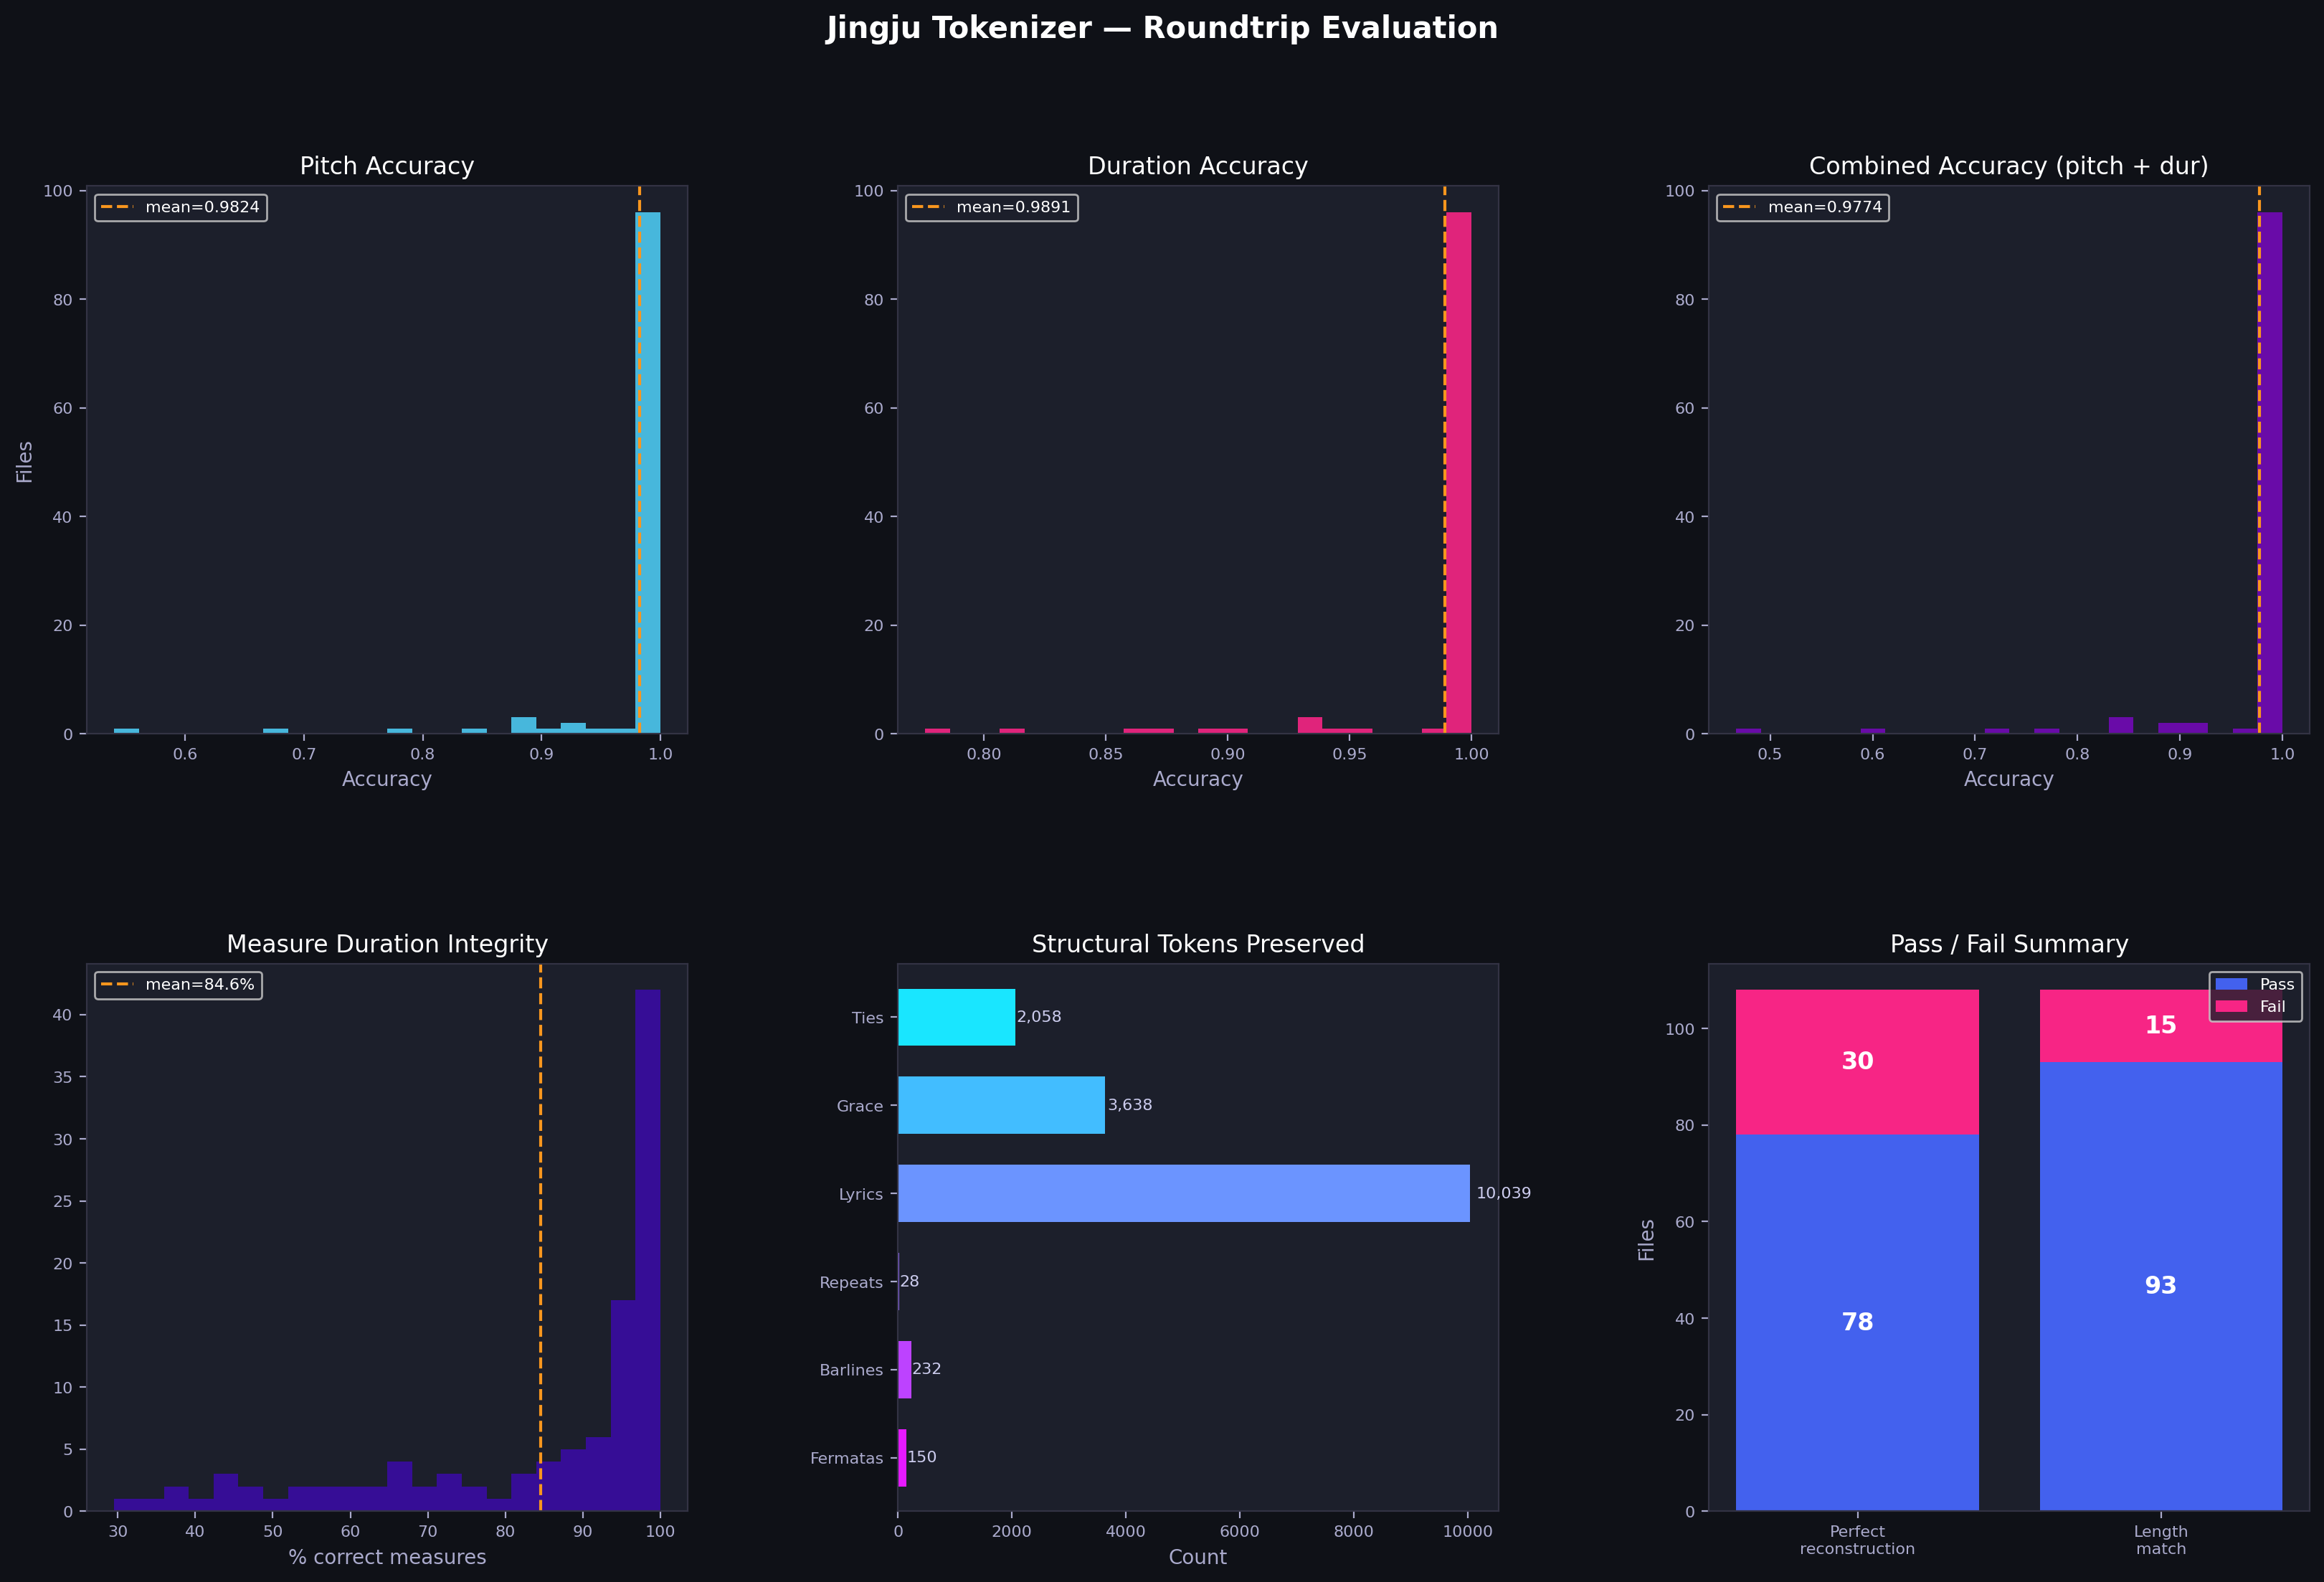

Saved evaluation.png


In [30]:
fig2 = plt.figure(figsize=(20,12), facecolor=_DARK)
fig2.suptitle("Jingju Tokenizer — Roundtrip Evaluation", color="white",
              fontsize=15, fontweight="bold", y=0.98)
gs2 = gridspec.GridSpec(2,3,figure=fig2,hspace=0.42,wspace=0.35)

ax = dark_ax(fig2.add_subplot(gs2[0,0]))
ax.hist(edf_ok["pitch_acc"], bins=22, color=_ACCENT[0], edgecolor="none", alpha=0.9)
ax.axvline(edf_ok["pitch_acc"].mean(), color="#f8961e", linestyle="--", linewidth=1.5,
           label=f"mean={edf_ok['pitch_acc'].mean():.4f}")
ax.set_title("Pitch Accuracy"); ax.set_xlabel("Accuracy"); ax.set_ylabel("Files")
ax.legend(fontsize=8,facecolor=_PANEL,labelcolor="white")

ax = dark_ax(fig2.add_subplot(gs2[0,1]))
ax.hist(edf_ok["dur_acc"], bins=22, color=_ACCENT[1], edgecolor="none", alpha=0.9)
ax.axvline(edf_ok["dur_acc"].mean(), color="#f8961e", linestyle="--", linewidth=1.5,
           label=f"mean={edf_ok['dur_acc'].mean():.4f}")
ax.set_title("Duration Accuracy"); ax.set_xlabel("Accuracy")
ax.legend(fontsize=8,facecolor=_PANEL,labelcolor="white")

ax = dark_ax(fig2.add_subplot(gs2[0,2]))
ax.hist(edf_ok["combined_acc"], bins=22, color=_ACCENT[2], edgecolor="none", alpha=0.9)
ax.axvline(edf_ok["combined_acc"].mean(), color="#f8961e", linestyle="--", linewidth=1.5,
           label=f"mean={edf_ok['combined_acc'].mean():.4f}")
ax.set_title("Combined Accuracy (pitch + dur)"); ax.set_xlabel("Accuracy")
ax.legend(fontsize=8,facecolor=_PANEL,labelcolor="white")

ax = dark_ax(fig2.add_subplot(gs2[1,0]))
ax.hist(edf_ok["measure_integrity"], bins=22, color=_ACCENT[3], edgecolor="none", alpha=0.9)
ax.axvline(edf_ok["measure_integrity"].mean(), color="#f8961e", linestyle="--", linewidth=1.5,
           label=f"mean={edf_ok['measure_integrity'].mean():.1f}%")
ax.set_title("Measure Duration Integrity"); ax.set_xlabel("% correct measures")
ax.legend(fontsize=8,facecolor=_PANEL,labelcolor="white")

ax = dark_ax(fig2.add_subplot(gs2[1,1]))
feat_labels2=[l for l,c in feat_cols if int(edf_ok[c].sum())>0]
feat_vals2  =[int(edf_ok[c].sum()) for l,c in feat_cols if int(edf_ok[c].sum())>0]
bar_cols2   = plt.cm.cool(np.linspace(0.1,0.9,len(feat_labels2)))
hb=ax.barh(feat_labels2,feat_vals2,color=bar_cols2,edgecolor="none",height=0.65)
ax.invert_yaxis()
for b,v in zip(hb,feat_vals2):
    ax.text(v*1.01,b.get_y()+b.get_height()/2,f"{v:,}",va="center",fontsize=8,color="#ccccee")
ax.set_title("Structural Tokens Preserved"); ax.set_xlabel("Count")

ax = dark_ax(fig2.add_subplot(gs2[1,2]))
n_ok=len(edf_ok); n_perf=int(perfect); n_lm=int(lmatch)
cats=["Perfect\nreconstruction","Length\nmatch"]
yes_v=[n_perf,n_lm]; no_v=[n_ok-n_perf,n_ok-n_lm]
x_pos=np.arange(len(cats))
ax.bar(x_pos,yes_v,color=_ACCENT[4],edgecolor="none",label="Pass")
ax.bar(x_pos,no_v,bottom=yes_v,color=_ACCENT[1],edgecolor="none",label="Fail")
ax.set_xticks(x_pos); ax.set_xticklabels(cats)
ax.set_title("Pass / Fail Summary"); ax.set_ylabel("Files")
ax.legend(fontsize=8,facecolor=_PANEL,labelcolor="white")
for xi,(y,n) in enumerate(zip(yes_v,no_v)):
    if y>0: ax.text(xi,y/2,str(y),ha="center",va="center",fontsize=12,color="white",fontweight="bold")
    if n>0: ax.text(xi,y+n/2,str(n),ha="center",va="center",fontsize=12,color="white",fontweight="bold")

plt.savefig(SUBMISSION_DIR/"evaluation.png",dpi=150,bbox_inches="tight",facecolor=_DARK)
plt.show()
print("Saved evaluation.png")

## Vocabulary Integer Export

In [31]:
v4_freq: Counter = Counter()
v4_seqs: List[List[str]] = []
v4_names: List[str] = []

for fp in ALL_FILES:
    try:
        toks=tokenize(str(fp)); v4_seqs.append(toks)
        v4_names.append(fp.name); v4_freq.update(toks)
    except: pass

vocab    = ["<PAD>"] + [t for t,_ in v4_freq.most_common()]
token2id = {t:i for i,t in enumerate(vocab)}
id2token = {i:t for t,i in token2id.items()}
id_seqs  = [[token2id[t] for t in s] for s in v4_seqs]
n_total  = sum(len(s) for s in v4_seqs)

print(f"Vocabulary size : {len(token2id):,}  (incl. <PAD>)")
print(f"Total tokens    : {n_total:,}")
print(f"Files encoded   : {len(v4_seqs)}")
print(f"Mean/min/max    : {n_total/max(1,len(v4_seqs)):.0f} / {min(len(s) for s in v4_seqs)} / {max(len(s) for s in v4_seqs)}")

xp = SUBMISSION_DIR/"corpus_tokenized_v4.json"
with open(xp,"w") as f:
    json.dump({"vocab":token2id,"id2token":{str(k):v for k,v in id2token.items()},
               "sequences":id_seqs,"filenames":v4_names,
               "metadata":{"n_files":len(v4_seqs),"n_tokens":n_total,
                            "vocab_size":len(token2id),"version":"v4"}},f)
print(f"\nExported → {xp}  ({xp.stat().st_size/1024/1024:.1f} MB)")

print("\nTop 20 tokens:")
print(f"  {'ID':>5}  {'Token':<38} {'Count':>8}  {'%':>6}")
print(f"  {'─'*5}  {'─'*38} {'─'*8}  {'─'*6}")
for tok,cnt in v4_freq.most_common(20):
    print(f"  {token2id[tok]:>5}  {tok:<38} {cnt:>8,}  {cnt/n_total*100:>5.2f}%")

Vocabulary size : 6,862  (incl. <PAD>)
Total tokens    : 694,560
Files encoded   : 108
Mean/min/max    : 6431 / 344 / 28708

Exported → /content/submission/corpus_tokenized_v4.json  (2.8 MB)

Top 20 tokens:
     ID  Token                                     Count       %
  ─────  ────────────────────────────────────── ────────  ──────
      1  STAFF_1                                 105,266  15.16%
      2  VOICE_1                                 105,266  15.16%
      3  DUR_1/4                                  51,508   7.42%
      4  DUR_1/2                                  37,387   5.38%
      5  POS_BAR_0                                22,838   3.29%
      6  PITCH_C#4                                14,066   2.03%
      7  PITCH_G#4                                13,941   2.01%
      8  POS_BAR_1/2                              12,677   1.83%
      9  PITCH_F#4                                12,222   1.76%
     10  PITCH_B4                                 11,978   1.72%
     11  POS_